In [1]:
!pip uninstall torch torchvision torchaudio ultralytics -y

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: ultralytics 8.4.48
Uninstalling ultralytics-8.4.48:
  Successfully uninstalled ultralytics-8.4.48


In [2]:
!pip install --force-reinstall torch torchvision --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (2449.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp311-cp311-win_amd64.whl (6.1 MB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.1.1-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached https://download.pytorc

  You can safely remove it manually.

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install ultralytics

  Using cached ultralytics-8.4.48-py3-none-any.whl.metadata (39 kB)
Using cached ultralytics-8.4.48-py3-none-any.whl (1.2 MB)



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install roboflow


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install load_dotenv


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import os
import ultralytics
from IPython.display import clear_output
from ultralytics import YOLO
import torch
from PIL import Image
from roboflow import Roboflow
import matplotlib.pyplot as plt

ultralytics.checks()
clear_output()

In [7]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Ninguna")

True
NVIDIA T500


In [8]:
DRIVE_URL = '/content/drive'
LOCAL_PATH = os.getcwd()

In [9]:
def detect_environment():
    try:
        ipython_env = str(get_ipython())

        if 'google.colab' in ipython_env:
            return "Google Colab"
        elif 'zmqshell' in ipython_env:
            return "Jupyter Notebook Local"
        else:
            return "Terminal interactiva de Python"
    except NameError:
        return "Script de Python estándar (.py)"


print(f"Entorno detectado: {detect_environment()}")

Entorno detectado: Jupyter Notebook Local


In [10]:
if detect_environment() != "Google Colab":
    BASE = LOCAL_PATH
else:
    BASE = DRIVE_URL
    from google.colab import drive
    drive.mount('/content/drive')
    from google.colab import userdata

In [11]:
BASE_IMGS = os.path.join(BASE, "imgs")
BASE_MODELS = os.path.join(BASE, "models")
BASE_DATA = os.path.join(BASE, "data")
BASE_RESULTS = os.path.join(BASE, "results")
BASE_PROJECT = os.path.join(BASE_DATA, "bccd-1")

In [12]:
os.makedirs(BASE_IMGS, exist_ok=True)
os.makedirs(BASE_MODELS, exist_ok=True)
os.makedirs(BASE_DATA, exist_ok=True)
os.makedirs(BASE_RESULTS, exist_ok=True)
os.makedirs(BASE_PROJECT, exist_ok=True)

In [13]:
model_n= YOLO(os.path.join(BASE_MODELS, "yolov8n.pt"))

In [14]:
result_n = model_n.predict(os.path.join(BASE_IMGS, "imagen_yolo.jpg"))


image 1/1 C:\Users\Sebastian-EDU\Documents\GitHub\EvolutionaryComputation\RoboFlow\imgs\imagen_yolo.jpg: 384x640 15 persons, 8 chairs, 4 tvs, 13 laptops, 1 mouse, 1 keyboard, 1 cell phone, 73.3ms
Speed: 3.4ms preprocess, 73.3ms inference, 20.6ms postprocess per image at shape (1, 3, 384, 640)


In [15]:
result_n[0].names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [16]:
result_n[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 0., 56.,  0.,  0., 56., 63., 56., 56.,  0., 63.,  0., 56.,  0., 64., 62., 66., 63.,  0.,  0., 63., 62.,  0.,  0.,  0.,  0.,  0., 63., 63., 63., 63., 62., 63., 62., 63.,  0., 63., 56., 63., 56., 67.,  0., 63., 56.], device='cuda:0')
conf: tensor([0.9000, 0.8309, 0.7724, 0.7669, 0.7464, 0.7436, 0.6796, 0.6588, 0.6244, 0.5915, 0.5911, 0.5597, 0.5512, 0.5447, 0.5372, 0.5201, 0.5134, 0.5041, 0.5000, 0.4919, 0.4675, 0.4631, 0.4598, 0.4131, 0.4018, 0.3993, 0.3988, 0.3968, 0.3963, 0.3769, 0.3679, 0.3543, 0.3534, 0.3514, 0.3514, 0.3490, 0.3197, 0.3149, 0.3135,
        0.2993, 0.2721, 0.2694, 0.2657], device='cuda:0')
data: tensor([[4.5154e+02, 3.3496e+02, 8.5333e+02, 7.1451e+02, 8.9998e-01, 0.0000e+00],
        [5.3110e-01, 3.5476e+02, 1.6458e+02, 5.8967e+02, 8.3094e-01, 5.6000e+01],
        [3.4255e+02, 2.1444e+02, 4.3253e+02, 3.5014e+02, 7.7237e-01, 0.0000e+00],
        [7.8259e+02, 2.8504e+02, 9.4445e+02, 5.8870e+02, 7.6

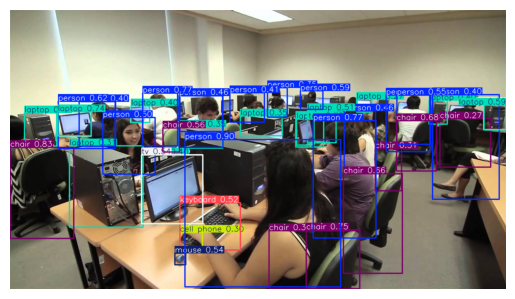

In [17]:
for r in result_n:
    im_array = r.plot(line_width=2)
    im_rgb = im_array[...,::-1]
    im = Image.fromarray(im_rgb)
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.show()
    im.save(os.path.join(BASE_IMGS, "detection_n.jpg"))

# Entrenamiento de Modelo

In [18]:
model_s= YOLO(os.path.join(BASE_MODELS, "yolov8s.pt"))

In [19]:
def setup_roboflow_credentials():
    env = detect_environment()
    api_key = None

    if env == "colab":
        try:
            api_key = userdata.get('ROBOFLOW_API_KEY')
            print("Credenciales de Roboflow cargadas desde Secretos de Colab.")
        except Exception:
            print("Configura 'ROBOFLOW_API_KEY' en los secretos de Colab.")
    else:
        try:
            from dotenv import load_dotenv
            load_dotenv()
        except ImportError:
            print("python-dotenv no está instalado. Usando variables de entorno del sistema...")

        api_key = os.environ.get('ROBOFLOW_API_KEY')

        if api_key:
            print("Credenciales de Roboflow cargadas desde variables de entorno (.env).")
        else:
            print("No se encontró 'ROBOFLOW_API_KEY' en el entorno local.")

    return api_key

In [20]:
rf_api_key = setup_roboflow_credentials()

Credenciales de Roboflow cargadas desde variables de entorno (.env).


In [21]:
if rf_api_key:
    try:
        rf = Roboflow(api_key=rf_api_key)

        workspace_name = 'yolov8-rdmbf'
        project_name = 'bccd-f0tcy'

        print(f"Descargando proyecto '{project_name}' del workspace '{workspace_name}'...")

        project = rf.workspace(workspace_name).project(project_name)
        version = project.version(1)
        os.chdir(BASE_DATA)
        dataset = version.download("yolov8")
        os.chdir(BASE)
        print("Dataset descargado correctamente en:", BASE_DATA)

    except Exception as e:
        print(f"Ocurrió un error al conectar con Roboflow: {e}")
else:
    print("Ejecución detenida: No hay credenciales válidas para Roboflow.")

Descargando proyecto 'bccd-f0tcy' del workspace 'yolov8-rdmbf'...
loading Roboflow workspace...
loading Roboflow project...
Dataset descargado correctamente en: C:\Users\Sebastian-EDU\Documents\GitHub\EvolutionaryComputation\RoboFlow\data


In [23]:
result= model_s.train(data=os.path.join(BASE_PROJECT, "data.yaml"), project= BASE_RESULTS, name='bccd_custom_training', epochs=10, imgsz=416, batch=8,device=0, amp=False, workers=4, cache=True, optimizer='auto')

Ultralytics 8.4.48  Python-3.11.2 torch-2.5.1+cu121 CUDA:0 (NVIDIA T500, 4096MiB)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Sebastian-EDU\Documents\GitHub\EvolutionaryComputation\RoboFlow\data\bccd-1\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\Sebastian-EDU\Documents\GitHub\EvolutionaryComputation\RoboFlow\models\yolov8s.pt, momentum=0.9

OSError: [Errno 22] Invalid argument: 'C:\\Users\\Sebastian-EDU\\Documents\\GitHub\\EvolutionaryComputation\\RoboFlow\\results\\bccd_custom_training-5\\weights\\last.pt'

In [24]:
result_l = model_s.predict(os.path.join(BASE_IMGS, "imagen_yolo.jpg"), save= True, show=False, conf=0.25)


image 1/1 C:\Users\Sebastian-EDU\Documents\GitHub\EvolutionaryComputation\RoboFlow\imgs\imagen_yolo.jpg: 384x640 6 -s, 83.2ms
Speed: 9.0ms preprocess, 83.2ms inference, 5.0ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\Sebastian-EDU\Documents\GitHub\EvolutionaryComputation\runs\detect\predict


In [25]:
result_l[0].names

{0: '-',
 1: 'BCCD - v4 416x416_aug',
 2: 'This dataset was exported via roboflow.com on January 13- 2023 at 5-48 PM GMT'}

In [26]:
result_l[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0., 0., 0., 0., 0.], device='cuda:0')
conf: tensor([0.5191, 0.5139, 0.4469, 0.3460, 0.3452, 0.2763], device='cuda:0')
data: tensor([[1.5305e+01, 3.5097e+02, 1.6851e+02, 4.9395e+02, 5.1910e-01, 0.0000e+00],
        [3.2868e+02, 2.1679e+02, 4.6543e+02, 3.7053e+02, 5.1391e-01, 0.0000e+00],
        [3.6125e+02, 5.8090e+02, 5.2984e+02, 7.1846e+02, 4.4690e-01, 0.0000e+00],
        [4.0391e+02, 4.1964e+00, 4.9806e+02, 1.4212e+02, 3.4598e-01, 0.0000e+00],
        [6.5035e+02, 3.8345e+02, 7.9262e+02, 5.4661e+02, 3.4523e-01, 0.0000e+00],
        [8.0531e+02, 3.6600e+02, 9.4792e+02, 4.6280e+02, 2.7625e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (720, 1280)
shape: torch.Size([6, 6])
xywh: tensor([[ 91.9082, 422.4596, 153.2061, 142.9857],
        [397.0558, 293.6632, 136.7439, 153.7371],
        [445.5459, 649.6765, 168.5917, 137.5607],
        [450.9863,  73.1594,  94.1523, 137.9258],
        [7

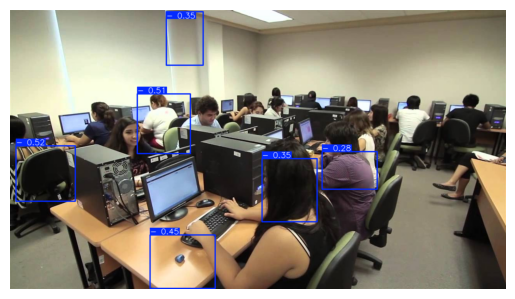

In [27]:
for r in result_l:
    im_array = r.plot(line_width=2)
    im_rgb = im_array[...,::-1]
    im = Image.fromarray(im_rgb)
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.show()
    im.save(os.path.join(BASE_IMGS, "detection_s.jpg"))